In [3]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import f1_score



def load_results(results_dir="results"):
    data = {}
    for fname in sorted(os.listdir(results_dir)):
        if not fname.endswith(".pkl"):
            continue
        key = fname.replace("_results.pkl", "")
        with open(os.path.join(results_dir, fname), "rb") as f:
            data[key] = pickle.load(f)
    return data

def f1_from_confusion(cm_dict):
    """Macro F1 from a stored confusion matrix dict."""
    matrix = cm_dict["matrix"]
    n = matrix.shape[0]
    y_true, y_pred = [], []
    for i in range(n):
        for j in range(n):
            count = matrix[i, j]
            y_true.extend([i] * count)
            y_pred.extend([j] * count)
    if not y_true:
        return 0.0
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

def compute_metrics(model_results):
    """Aggregate per-task metrics into per-category and overall means."""
    cats = {"algorithmic": [], "linguistic": [], "knowledge": [], "all": []}
    for task_name, v in model_results.items():
        prefix = task_name.split("_")[0]
        row = {
            "baseline_acc":  float(v["baseline_accuracy"]),
            "icl_acc":       float(v["icl_accuracy"]),
            "baseline_f1":   f1_from_confusion(v["baseline_confusion_matrix"]),
            "icl_f1":        f1_from_confusion(v["icl_confusion_matrix"]),
            "baseline_time": float(v["baseline_time"]),
            "icl_time":      float(v["icl_time"]),
        }
        cats["all"].append(row)
        if prefix in cats:
            cats[prefix].append(row)
    return {
        cat: {k: np.mean([r[k] for r in rows]) for k in rows[0]}
        for cat, rows in cats.items() if rows
    }



In [4]:


all_results = load_results()

# Parse model label → (arch, size_label, size_order)
SIZE_ORDER = {"5M_SimpleStories": 0, "~130M_pile": 1, "~370M_pile": 2,
              "~790M_pile": 3, "~1.4B_pile": 4, "~2.8B_pile": 5}

models = {}
for key in all_results:
    parts = key.split("_", 1)
    arch, size = parts[0], parts[1]
    models[key] = {"arch": arch, "size": size, "order": SIZE_ORDER.get(size, 99),
                   "metrics": compute_metrics(all_results[key])}

ssm_keys  = sorted([k for k in models if models[k]["arch"] == "ssm"],
                   key=lambda k: models[k]["order"])
tr_keys   = sorted([k for k in models if models[k]["arch"] == "transformer"],
                   key=lambda k: models[k]["order"])

size_labels = [models[k]["size"] for k in ssm_keys]

CATEGORIES = ["all", "algorithmic", "linguistic", "knowledge"]
METRIC_PAIRS = [
    ("icl_acc",   "baseline_acc",   "Accuracy",      "ICL",      "Baseline"),
    ("icl_f1",    "baseline_f1",    "Macro F1",       "ICL",      "Baseline"),
    ("icl_time",  "baseline_time",  "Inference Time (s)", "ICL", "Baseline"),
]

ARCH_COLORS = {
    "ssm":  {"ICL": "#1f77b4", "Baseline": "#aec7e8"},
    "transformer": {"ICL": "#d62728", "Baseline": "#f5a0a0"},
}



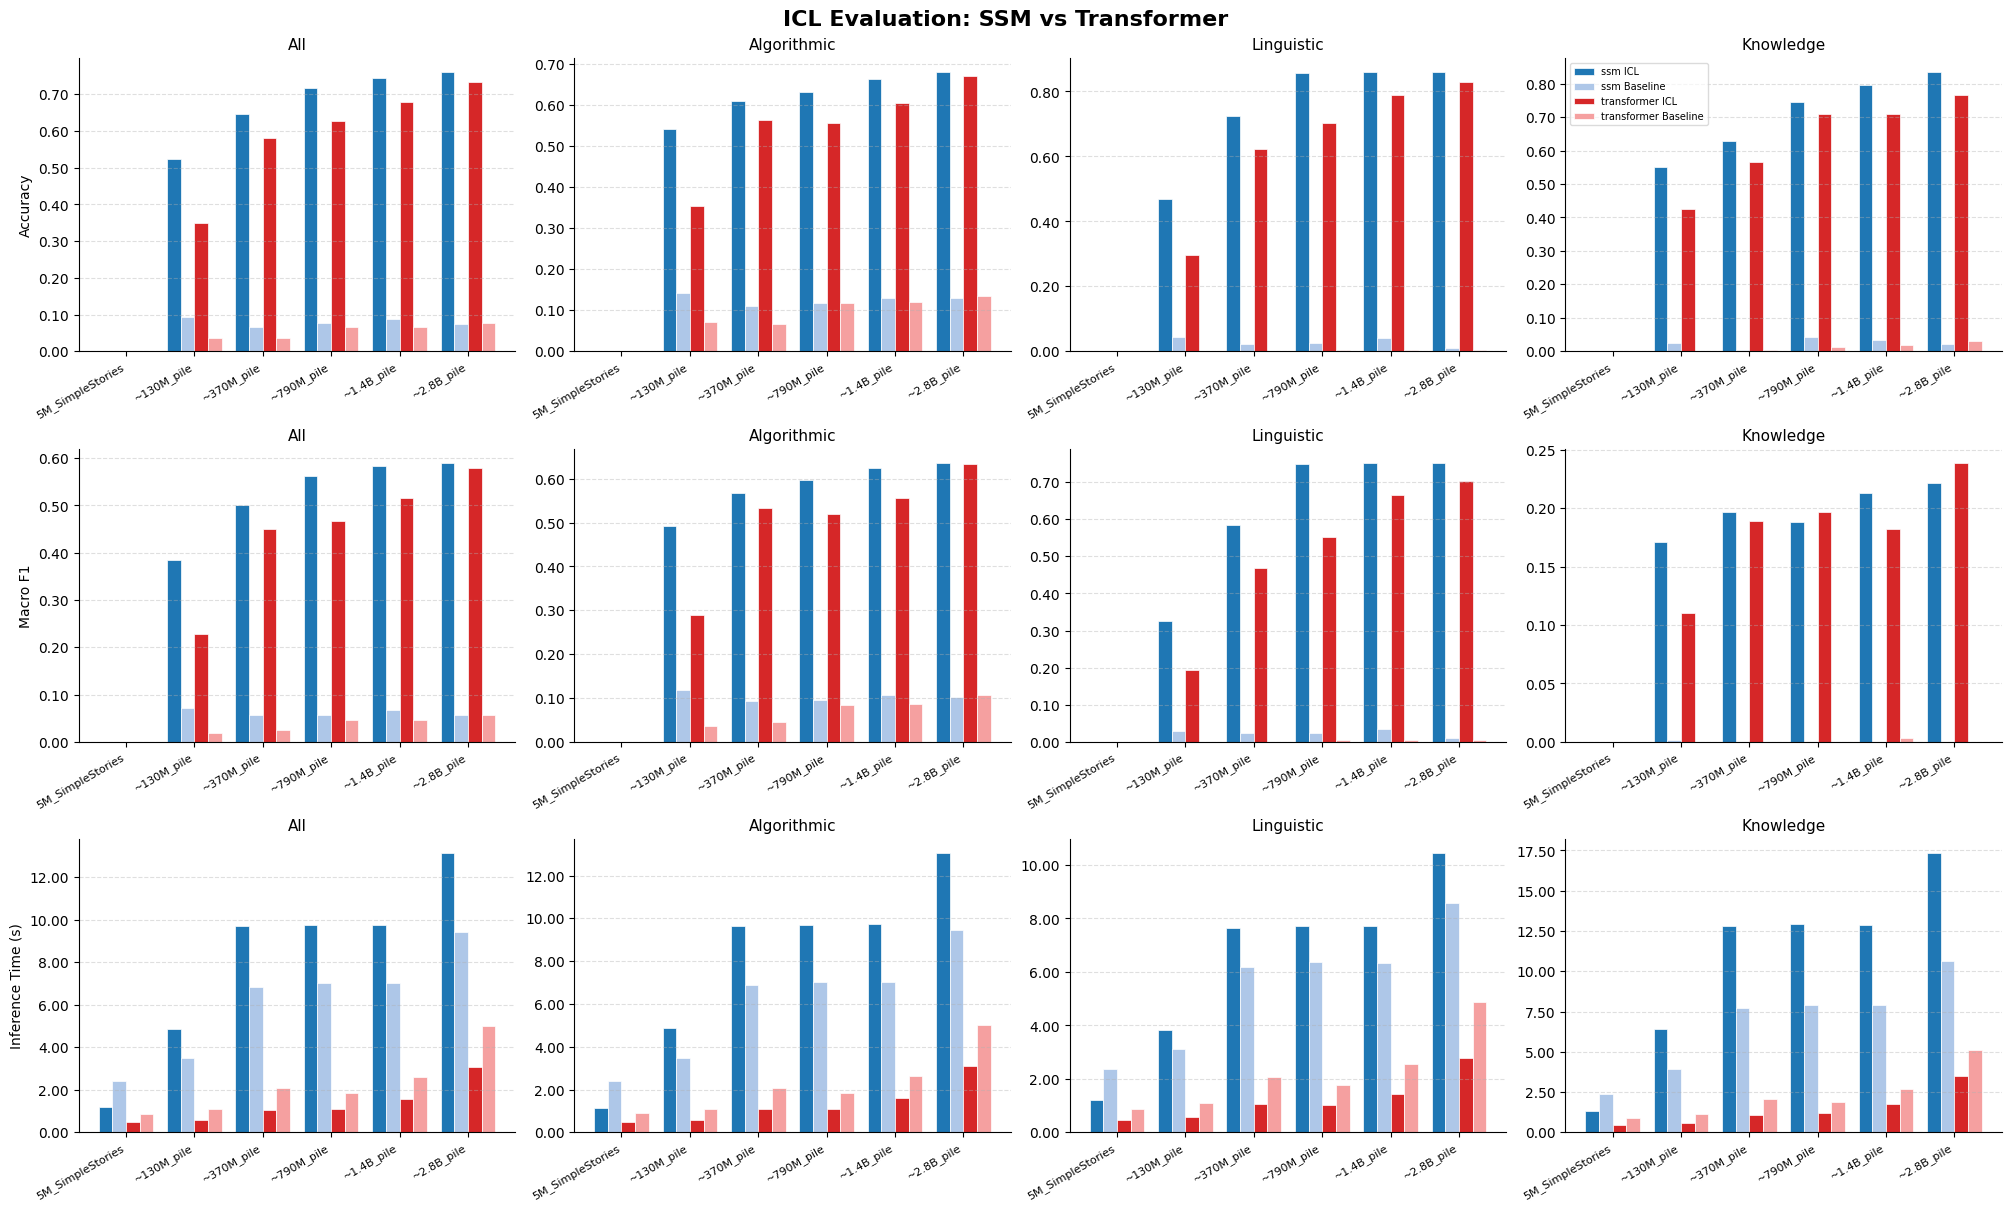

Saved to experiments/results/icl_results_overview.png


In [6]:


fig, axes = plt.subplots(
    nrows=len(METRIC_PAIRS), ncols=len(CATEGORIES),
    figsize=(5 * len(CATEGORIES), 4 * len(METRIC_PAIRS)),
    constrained_layout=True,
)
fig.suptitle("ICL Evaluation: SSM vs Transformer", fontsize=16, fontweight="bold")

x = np.arange(len(size_labels))
bar_w = 0.2

for row_idx, (icl_key, base_key, metric_label, icl_label, base_label) in enumerate(METRIC_PAIRS):
    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[row_idx][col_idx]

        for arch_idx, (keys, arch) in enumerate([(ssm_keys, "ssm"), (tr_keys, "transformer")]):
            icl_vals  = [models[k]["metrics"].get(cat, {}).get(icl_key,  0) for k in keys]
            base_vals = [models[k]["metrics"].get(cat, {}).get(base_key, 0) for k in keys]

            offset_icl  = (arch_idx * 2)     * bar_w - 1.5 * bar_w
            offset_base = (arch_idx * 2 + 1) * bar_w - 1.5 * bar_w

            ax.bar(x + offset_icl,  icl_vals,  bar_w,
                   label=f"{arch} {icl_label}",
                   color=ARCH_COLORS[arch][icl_label], edgecolor="white", linewidth=0.5)
            ax.bar(x + offset_base, base_vals, bar_w,
                   label=f"{arch} {base_label}",
                   color=ARCH_COLORS[arch][base_label], edgecolor="white", linewidth=0.5)

        ax.set_title(f"{cat.capitalize()}", fontsize=11)
        ax.set_ylabel(metric_label if col_idx == 0 else "")
        ax.set_xticks(x)
        ax.set_xticklabels(size_labels, rotation=30, ha="right", fontsize=8)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.spines[["top", "right"]].set_visible(False)

        if row_idx == 0 and col_idx == len(CATEGORIES) - 1:
            ax.legend(fontsize=7, loc="upper left", framealpha=0.7)

plt.savefig("results/icl_results_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to experiments/results/icl_results_overview.png")
